     Crop  Avg Temperature (°C)  Annual Rainfall (mm)  Humidity (%)  \
0   Onion                 14.56                608.55         32.79   
1  Cotton                 23.79               2483.41         71.51   
2   Mango                 26.86               2741.35         40.22   
3  Banana                 19.78               2386.09         70.48   
4  Tomato                 35.36               2038.30         36.52   

   Wind Speed (km/h)  Sunlight Hours (per day)  Soil Moisture (%)  \
0              15.64                      8.53              46.39   
1              11.48                     11.17              35.61   
2               6.03                      7.43              40.13   
3              11.26                      9.74              49.85   
4              15.34                      4.99              24.89   

  Drought Risk Flood Risk Suitable Season  
0          Low       High         Monsoon  
1          Low        Low          Spring  
2         High       High 

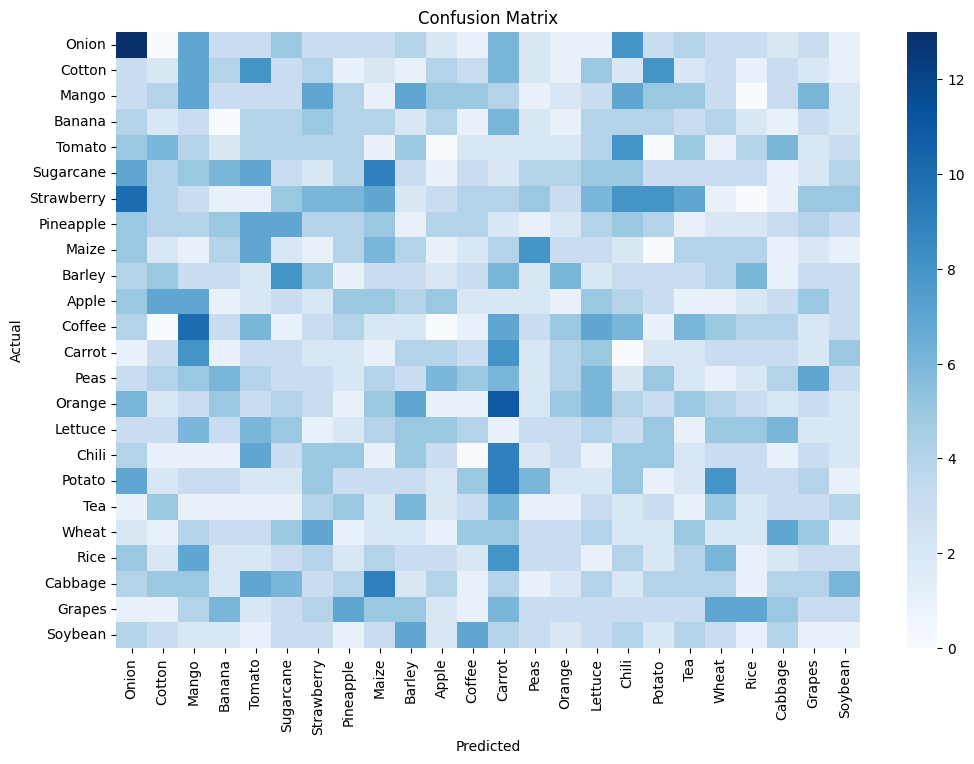

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
dataset_path = "/content/climate_prediction_dataset.csv"  # Change this if needed
df = pd.read_csv(dataset_path)

# Display first few rows
print(df.head())

# Convert categorical columns into numerical using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=["Drought Risk", "Flood Risk", "Suitable Season"])

# Define feature set (X) and target variable (y)
X = df_encoded.drop(columns=["Crop"])  # Features
y = df["Crop"]  # Target variable (Crop name)

# Convert target variable into classification labels
y = y.astype('category').cat.codes

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\n🔹 Accuracy: {accuracy * 2000:.2f}%\n")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=df["Crop"].unique(), yticklabels=df["Crop"].unique())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()